### 1. Setting up the environment

In [5]:
import pandas as pd
import numpy as np     
import matplotlib.pyplot as plt
import folium

### 2. Importing the dataset

In [6]:
sps_df = pd.read_csv('D:\\datasets\\SuperStore analysis project\\superstore-sales-analysis\\Superstore.csv', encoding='latin1')

### 3. Exploratory Data Analysis (EDA) - Dataset overview

In [7]:
sps_df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
sps_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
sps_df.shape

(9994, 21)

In [10]:
sps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [11]:
sps_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [12]:
sps_df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Checking for duplicate values

In [13]:
sps_df.duplicated().sum()

np.int64(0)

### 4. Data Processing - Converting Order Date to datetime

In [14]:
sps_df['Order Date'] = pd.to_datetime(sps_df['Order Date'] , format='%d-%m-%Y')

Feature Engineering: Extracting the Year attribute

In [15]:
sps_df['Year'] = sps_df['Order Date'].dt.year

Feature Engineering: Extracting the Month attribute

In [16]:
sps_df['Month_Name'] = sps_df['Order Date'].dt.month_name()

In [17]:
sps_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month_Name
0,1,CA-2013-152156,2013-11-09,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2013,November
1,2,CA-2013-152156,2013-11-09,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2013,November
2,3,CA-2013-138688,2013-06-13,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2013,June
3,4,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2012,October
4,5,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2012,October


### 5. Data Analysis & Insights

#### Year-over-Year Profit Analysis

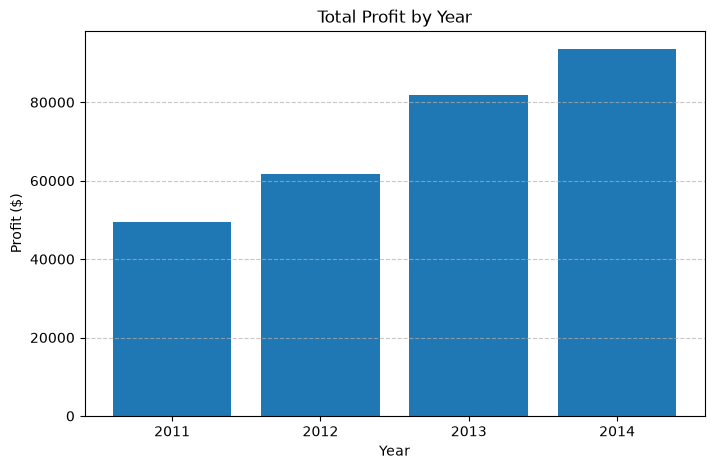

In [18]:
year_profit = sps_df.groupby('Year')['Profit'].sum().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(year_profit['Year'].astype(str), year_profit['Profit'], color='#1f77b4')
plt.title('Total Profit by Year')
plt.xlabel('Year')
plt.ylabel('Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### City-Level Performance Analysis

In [19]:
city_sales = sps_df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
city_sales

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64

#### Geographical Visualization Setup

In [20]:
city_sales_all = sps_df.groupby('City')['Sales'].sum().reset_index()
us_cities_coords = {
    'New York City': [40.7128, -74.0060], 'Los Angeles': [34.0522, -118.2437],
    'Seattle': [47.6062, -122.3321], 'San Francisco': [37.7749, -122.4194],
    'Philadelphia': [39.9526, -75.1652], 'Houston': [29.7604, -95.3698],
    'Chicago': [41.8781, -87.6298], 'San Diego': [32.7157, -117.1611],
    'Miami': [25.7617, -80.1918], 'Dallas': [32.7767, -96.7970],
    'Phoenix': [33.4484, -112.0740], 'Detroit': [42.3314, -83.0458],
    'Newark': [40.7357, -74.1724], 'Jacksonville': [30.3322, -81.6557],
    'Columbus': [39.9612, -82.9988], 'Atlanta': [33.7490, -84.3880],
    'Aurora': [39.7294, -104.8319], 'Charlotte': [35.2271, -80.8431]
}
coords_df = pd.DataFrame.from_dict(us_cities_coords, orient='index', columns=['Latitude', 'Longitude']).reset_index()
coords_df.rename(columns={'index': 'City'}, inplace=True)
city_data = pd.merge(city_sales_all, coords_df, on='City', how='inner')

m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)
for index, row in city_data.iterrows():
    radius = row['Sales'] / 4000
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=max(radius, 4),
        popup=f"<b>City:</b> {row['City']}<br><b>Total Sales:</b> ${row['Sales']:,.2f}",
        color='#1f77b4',
        fill=True,
        fill_color='#318dad',
        fill_opacity=0.6
    ).add_to(m)
m